# NB5 — End-to-End Diagnosis & Virtual Sensor Accommodation

**Upgraded**: The `DiagnosticOrchestrator` now auto-routes between:
- **ANN path** — FeaturePipeline → flat features → ANN
- **Sequence path** — raw windows → LSTM or Transformer (no FeaturePipeline needed)

The active model is determined from `checkpoints/nb3_meta.json`.
SHAP integration works for all three model types (reads from `shap_explainers.pkl`).


## 0 — Imports & configuration

In [1]:
import sys, os, gc, pickle, warnings, logging, json
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

sys.path.insert(0, '..')
from models import (
    ConvAutoencoder, AETrainer,
    MultiHeadANN, MultiHeadLSTM, MultiHeadTransformer,
    MCDropoutWrapper, apply_virtual_sensor, DEVICE,
)
from feature_engineering import FeaturePipeline
from explainability import SHAPExplainer, DiagnosticOrchestrator, DiagnosisReport
from fault_engine import FAULT_LABELS, FaultEngine

PROC_DIR = '../processed_data'
CKPT_DIR = '../checkpoints'
PLOT_DIR = '../plots'
label_names = {0:'Nominal',1:'Bias',2:'Scaling',3:'Drift',
               4:'Intermittent',5:'Compound',6:'MultiSensor',7:'SystemFault'}

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

2026-04-09 14:17:23,196 [INFO] NumExpr defaulting to 12 threads.
2026-04-09 14:17:26,170 [INFO] GPU: NVIDIA RTX 4500 Ada Generation


Device : cuda
GPU    : NVIDIA RTX 4500 Ada Generation


## 1 — Load all artefacts (auto-detects model type)

In [2]:
with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f:
    sensor_cols = pickle.load(f)

with open(f'{CKPT_DIR}/nb3_meta.json') as f:
    meta = json.load(f)

HEAD_TYPE    = meta['head_type']
USE_RESIDUAL = meta['use_residual']
N_SENSORS    = meta['n_sensors']
WINDOW_SIZE  = meta['window_size']
N_FAULT_TYPES= meta['n_fault_types']

print(f'HEAD_TYPE    : {HEAD_TYPE}')
print(f'USE_RESIDUAL : {USE_RESIDUAL}')

# ── Dataset ──────────────────────────────────────────────────────────────────
X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')
_raw      = np.load(f'{PROC_DIR}/augmented_dataset_with_recon.npz')
X_dataset   = _raw['X']
X_recon_all = _raw['X_rec']
y_fault     = _raw['y_f']
y_sensor    = _raw['y_s']
y_mag       = _raw['y_m']

# ── AE (always) ──────────────────────────────────────────────────────────────
ae_model = ConvAutoencoder(n_sensors=N_SENSORS, window_size=WINDOW_SIZE,
                            base_ch=32, latent_dim=64).to(DEVICE)
ae_model.load_state_dict(torch.load(f'{CKPT_DIR}/autoencoder.pt',
                                     map_location=DEVICE, weights_only=True))
ae_model.eval()
ae_trainer = AETrainer(ae_model, device=DEVICE)

# ── Classification head (prefer best val loss) ────────────────────────────────
best_val = meta.get('best_val_losses', {})

def _pick_active_model():
    """Pick the single best-performing model for the diagnosis orchestrator."""
    candidates = {k: v for k, v in best_val.items()
                  if os.path.exists(f'{CKPT_DIR}/{k.lower()}_multihead.pt')}
    if not candidates:
        raise FileNotFoundError('No trained classification heads found in checkpoints.')
    # Prefer sequence models if available and their val loss is ≤ ANN + 0.05
    ann_loss = candidates.get('ANN', float('inf'))
    for pref in ('Transformer', 'LSTM'):
        if pref in candidates and candidates[pref] <= ann_loss + 0.05:
            return pref
    return min(candidates, key=candidates.get)

ACTIVE_MODEL = _pick_active_model()
print(f'Active classification head: {ACTIVE_MODEL}  (val loss: {best_val.get(ACTIVE_MODEL)})')

HEAD_TYPE    : all
USE_RESIDUAL : True


2026-04-09 14:17:40,942 [INFO] AE Bottleneck: 1792 -> 64 -> 1792


Active classification head: LSTM  (val loss: 1.2107446193695068)


In [3]:
# ── Load the active model ─────────────────────────────────────────────────────
feat_pipe = None
F_all     = None

if ACTIVE_MODEL == 'ANN':
    _d = np.load(f'{PROC_DIR}/final_manifold_features.npz')
    F_all = _d['F']
    with open(f'{CKPT_DIR}/feature_pipeline.pkl', 'rb') as f:
        feat_pipe = pickle.load(f)
    active_clf = MultiHeadANN(
        in_features=F_all.shape[1], n_fault_types=N_FAULT_TYPES,
        n_sensors=len(sensor_cols), hidden_dims=[256, 128, 64], dropout_p=0.3,
    )
    active_clf.load_state_dict(torch.load(f'{CKPT_DIR}/ann_multihead.pt',
                                           map_location=DEVICE, weights_only=True))

elif ACTIVE_MODEL == 'LSTM':
    cfg = meta['lstm_config']
    active_clf = MultiHeadLSTM(
        n_sensors=N_SENSORS, hidden_size=cfg['hidden_size'],
        num_layers=cfg['num_layers'], n_fault_types=N_FAULT_TYPES,
        dropout_p=cfg['dropout_p'], use_residual=USE_RESIDUAL,
    )
    active_clf.load_state_dict(torch.load(f'{CKPT_DIR}/lstm_multihead.pt',
                                           map_location=DEVICE, weights_only=True))

elif ACTIVE_MODEL == 'Transformer':
    cfg = meta['transformer_config']
    active_clf = MultiHeadTransformer(
        n_sensors=N_SENSORS, d_model=cfg['d_model'], nhead=cfg['nhead'],
        num_layers=cfg['num_layers'], dim_feedforward=cfg['dim_feedforward'],
        n_fault_types=N_FAULT_TYPES, dropout_p=cfg['dropout_p'],
        use_residual=USE_RESIDUAL, store_attn=False,
    )
    active_clf.load_state_dict(torch.load(f'{CKPT_DIR}/transformer_multihead.pt',
                                           map_location=DEVICE, weights_only=True))

active_clf.to(DEVICE).eval()
mc_wrapper = MCDropoutWrapper(active_clf, T=100)

# ── SHAP explainer for active model ──────────────────────────────────────────
shap_explainer = None
if os.path.exists(f'{CKPT_DIR}/shap_explainers.pkl'):
    with open(f'{CKPT_DIR}/shap_explainers.pkl', 'rb') as f:
        all_explainers = pickle.load(f)
    if ACTIVE_MODEL in all_explainers:
        shap_explainer, _ = all_explainers[ACTIVE_MODEL]
        print(f'SHAP explainer loaded for {ACTIVE_MODEL}')
    else:
        print(f'No SHAP explainer found for {ACTIVE_MODEL} — explainability disabled')

# ── Nominal AE MAE (for severity calibration on sequence path) ───────────────
print('Computing nominal AE MAE for severity calibration …')
X_nom_sub = X_nominal[:min(2000, len(X_nominal))]
X_nom_rec = ae_trainer.reconstruct(X_nom_sub)
ae_nominal_mae = float(np.abs(X_nom_sub - X_nom_rec).mean())
print(f'Nominal AE MAE : {ae_nominal_mae:.6f}')

print('\n✓ All models and artefacts loaded.')

SHAP explainer loaded for LSTM
Computing nominal AE MAE for severity calibration …
Nominal AE MAE : 0.009359

✓ All models and artefacts loaded.


## 2 — Build DiagnosticOrchestrator

In [4]:
orchestrator = DiagnosticOrchestrator(
    ae_trainer      = ae_trainer,
    mc_wrapper      = mc_wrapper,
    sensor_cols     = sensor_cols,
    fault_labels    = FAULT_LABELS,
    shap_explainer  = shap_explainer,
    feature_pipe    = feat_pipe,          # None for LSTM/Transformer — ignored
    severity_thresh = 50.0,
    ae_nominal_mae  = ae_nominal_mae,
    model_type      = ACTIVE_MODEL,
    use_residual    = USE_RESIDUAL,
)
print(f'DiagnosticOrchestrator ready  [{ACTIVE_MODEL} path]')

2026-04-09 14:18:38,113 [INFO] DiagnosticOrchestrator ready  model_type=LSTM  use_residual=True


DiagnosticOrchestrator ready  [LSTM path]


## 3 — Batch diagnosis on test windows

In [5]:
N_TEST   = 100
test_idx = np.random.choice(len(X_dataset), N_TEST, replace=False)
X_test   = X_dataset[test_idx]

print(f'Running diagnosis on {N_TEST} windows ({ACTIVE_MODEL} path) …')
reports, X_final = orchestrator.diagnose_batch(X_test, stride_s=10.0)

print('\nSample reports (first 5):')
print('-' * 60)
for rpt in reports[:5]:
    print(rpt)
    print()

Running diagnosis on 100 windows (LSTM path) …

Sample reports (first 5):
------------------------------------------------------------
─── Diagnosis Report [Window 0] ───
  Timestamp      : 0.0 s
  Anomaly        : no
  Severity       : 40.3%
  Confidence     : 0.00
  Fault Type     : Intermittent (p=0.94)
  Sensor ID      : Nc (p=0.20)
  Magnitude (est): 1.2593 ± 0.0802
  Accommodation  : None

─── Diagnosis Report [Window 1] ───
  Timestamp      : 10.0 s
  Anomaly        : no
  Severity       : 39.8%
  Confidence     : 0.01
  Fault Type     : Bias (p=0.89)
  Sensor ID      : T24 (p=0.89)
  Magnitude (est): 0.6397 ± 0.0235
  Accommodation  : None

─── Diagnosis Report [Window 2] ───
  Timestamp      : 20.0 s
  Anomaly        : YES ⚠
  Severity       : 100.0%
  Confidence     : 1.00
  Fault Type     : Scaling (p=0.55)
  Sensor ID      : Ps30 (p=0.81)
  Magnitude (est): 0.6667 ± 0.0306
  Accommodation  : VirtualSensor
  Top SHAP features / regions:
    t20__P2                        +7.

## 4 — Full diagnostic dashboard

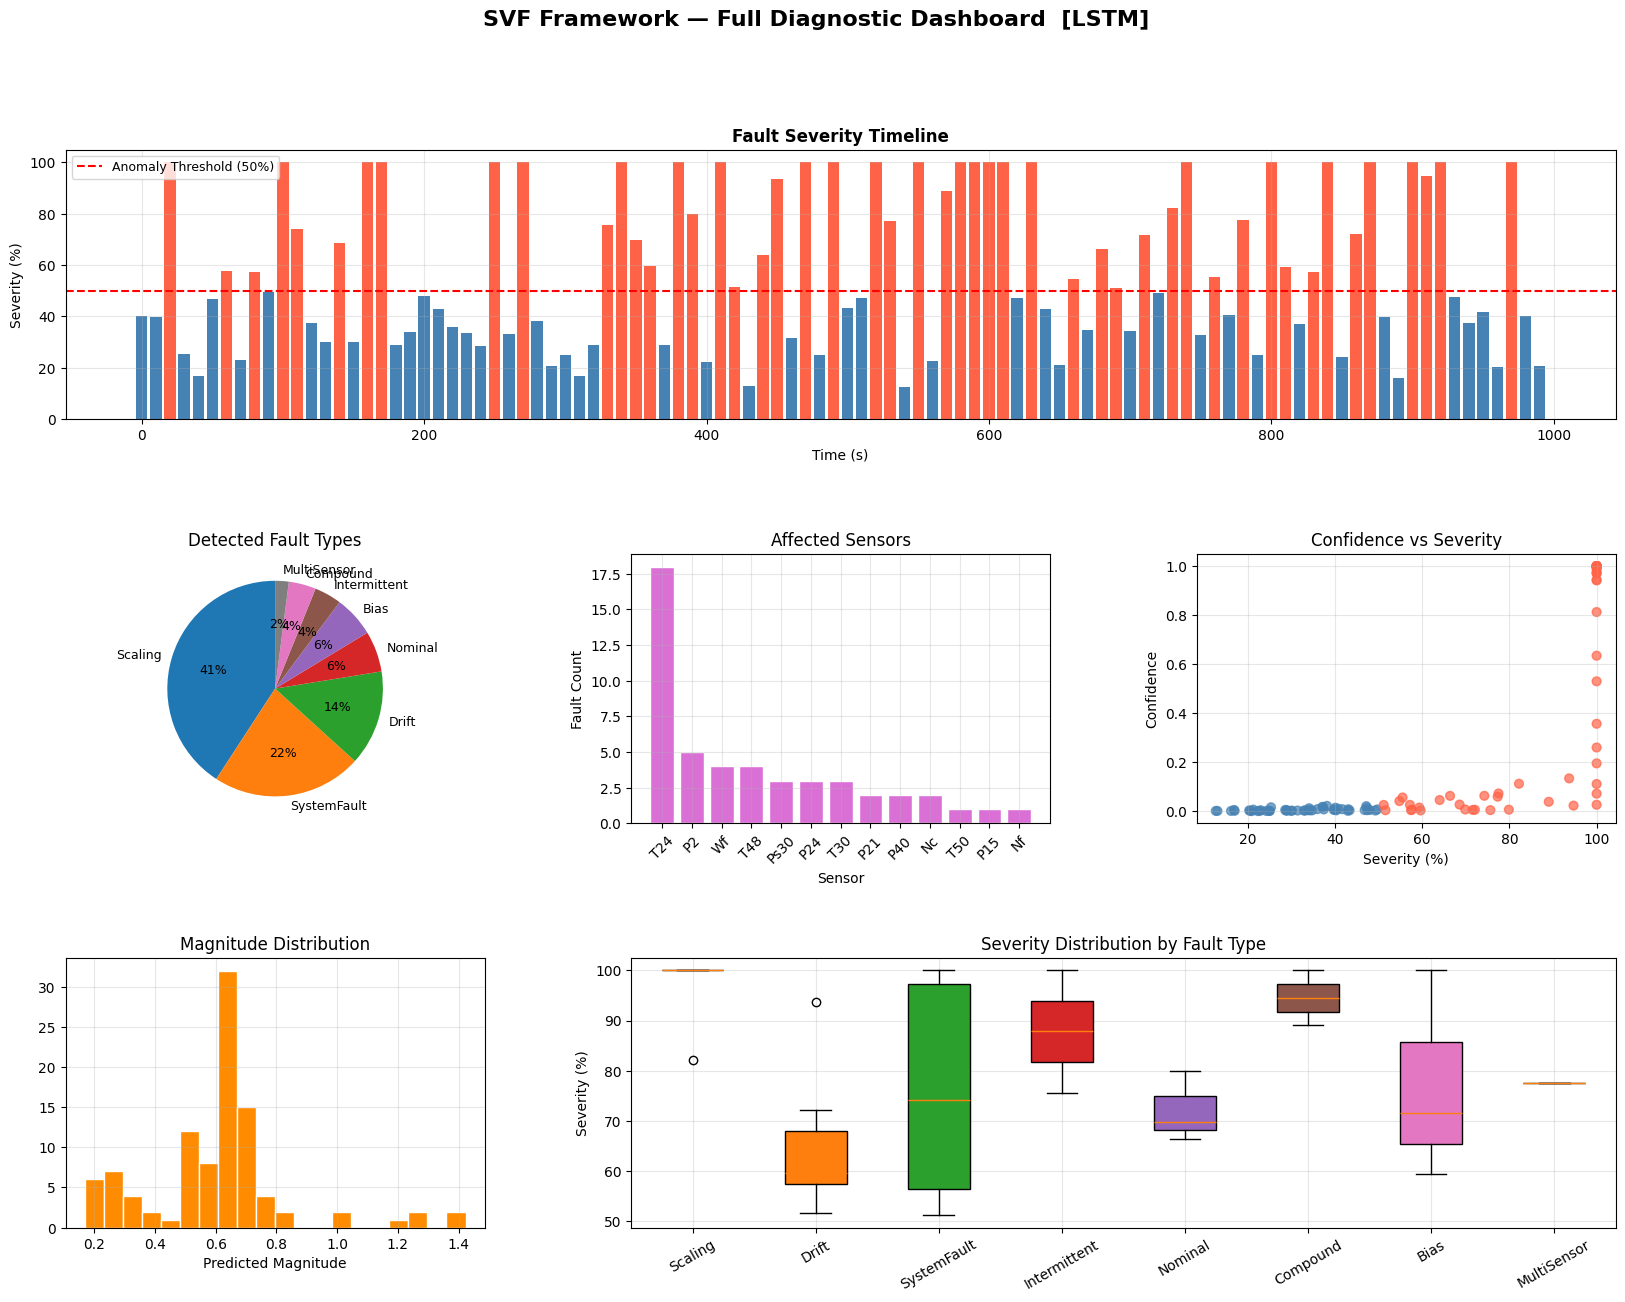

Anomalies detected: 49 / 100


In [6]:
rpt_df = pd.DataFrame([r.to_dict() for r in reports])

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.35)
fig.suptitle(f'SVF Framework — Full Diagnostic Dashboard  [{ACTIVE_MODEL}]',
             fontsize=16, fontweight='bold')

# ── 1. Severity timeline ──────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :])
colors_ = ['tomato' if a else 'steelblue' for a in rpt_df['is_anomaly']]
ax0.bar(rpt_df['timestamp_s'], rpt_df['severity_pct'], color=colors_, width=8)
ax0.axhline(50, color='red', ls='--', lw=1.5, label='Anomaly Threshold (50%)')
ax0.set_xlabel('Time (s)'); ax0.set_ylabel('Severity (%)')
ax0.set_title('Fault Severity Timeline', fontweight='bold')
ax0.legend(fontsize=9); ax0.grid(alpha=0.3)

# ── 2. Fault type pie ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
ft_counts = rpt_df[rpt_df['is_anomaly']]['fault_type'].value_counts()
if len(ft_counts) > 0:
    ax1.pie(ft_counts.values, labels=ft_counts.index, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 9})
ax1.set_title('Detected Fault Types')

# ── 3. Sensor affected bar ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])
s_counts = rpt_df[rpt_df['is_anomaly']]['sensor_id'].value_counts()
if len(s_counts) > 0:
    ax2.bar(s_counts.index, s_counts.values, color='orchid', edgecolor='white')
ax2.set_xlabel('Sensor'); ax2.set_ylabel('Fault Count')
ax2.set_title('Affected Sensors'); ax2.tick_params(axis='x', rotation=45); ax2.grid(alpha=0.3)

# ── 4. Confidence vs Severity scatter ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
cm_ = ['tomato' if a else 'steelblue' for a in rpt_df['is_anomaly']]
ax3.scatter(rpt_df['severity_pct'], rpt_df['confidence'], c=cm_, alpha=0.7, s=40)
ax3.set_xlabel('Severity (%)'); ax3.set_ylabel('Confidence')
ax3.set_title('Confidence vs Severity'); ax3.grid(alpha=0.3)

# ── 5. Magnitude distribution ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(rpt_df['magnitude_est'], bins=20, color='darkorange', edgecolor='white')
ax4.set_xlabel('Predicted Magnitude'); ax4.set_title('Magnitude Distribution'); ax4.grid(alpha=0.3)

# ── 6. Severity by fault type boxplot ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1:])
anomalies = rpt_df[rpt_df['is_anomaly']]
if len(anomalies) > 0:
    groups = [anomalies[anomalies['fault_type'] == ft]['severity_pct'].values
              for ft in anomalies['fault_type'].unique()]
    labels_ = list(anomalies['fault_type'].unique())
    bp = ax5.boxplot(groups, labels=labels_, patch_artist=True)
    for patch, color in zip(bp['boxes'], plt.cm.tab10.colors[:len(groups)]):
        patch.set_facecolor(color)
    ax5.set_ylabel('Severity (%)'); ax5.set_title('Severity Distribution by Fault Type')
    ax5.tick_params(axis='x', rotation=30); ax5.grid(alpha=0.3)

plt.savefig(f'{PLOT_DIR}/nb5_end_to_end_dashboard_{ACTIVE_MODEL.lower()}.png',
            dpi=130, bbox_inches='tight')
plt.show()
print(f'Anomalies detected: {rpt_df["is_anomaly"].sum()} / {len(rpt_df)}')

## 5 — Virtual sensor accommodation

In [7]:
# Pick anomalous windows from the full dataset (higher severity → more convincing demo)
from explainability import _apply_virtual

# Re-run anomaly scoring to get severity for whole dataset
# (use a sample to avoid slow full-dataset reconstruction)
DEMO_N = 500
demo_idx = np.random.choice(len(X_dataset), DEMO_N, replace=False)
X_demo     = X_dataset[demo_idx]
X_rec_demo = ae_trainer.reconstruct(X_demo)

mae_demo = np.abs(X_demo - X_rec_demo).mean(axis=(1, 2))
sev_demo = np.clip((mae_demo / (2.0 * ae_nominal_mae + 1e-9)) * 100.0, 0, 100)

# Pick top anomalous windows
anomaly_idx_demo = np.argsort(sev_demo)[::-1][:10]
drift_win   = X_demo[anomaly_idx_demo]
drift_recon = X_rec_demo[anomaly_idx_demo]
anomaly_mk  = (sev_demo[anomaly_idx_demo] > 50)

# Get sensor predictions from the active model
if ACTIVE_MODEL == 'ANN':
    # Need flat features for ANN
    F_anom = np.concatenate([
        feat_pipe.transform(drift_win[i:i+1], drift_recon[i:i+1])[0]
        for i in range(len(drift_win))
    ], axis=0)
    inp_t = torch.from_numpy(F_anom).float().to(DEVICE)
else:
    if USE_RESIDUAL:
        inp_np = np.concatenate(
            [drift_win, np.abs(drift_win - drift_recon).astype(np.float32)], axis=-1
        )
    else:
        inp_np = drift_win.astype(np.float32)
    inp_t = torch.from_numpy(inp_np).float().to(DEVICE)

sensor_preds = mc_wrapper.predict(inp_t, head='sensor')['pred_class'].cpu().numpy()

X_acc = _apply_virtual(drift_win, drift_recon, anomaly_mk, sensor_preds)
print(f'Windows accommodated: {anomaly_mk.sum()} / {len(anomaly_mk)}')

Windows accommodated: 10 / 10


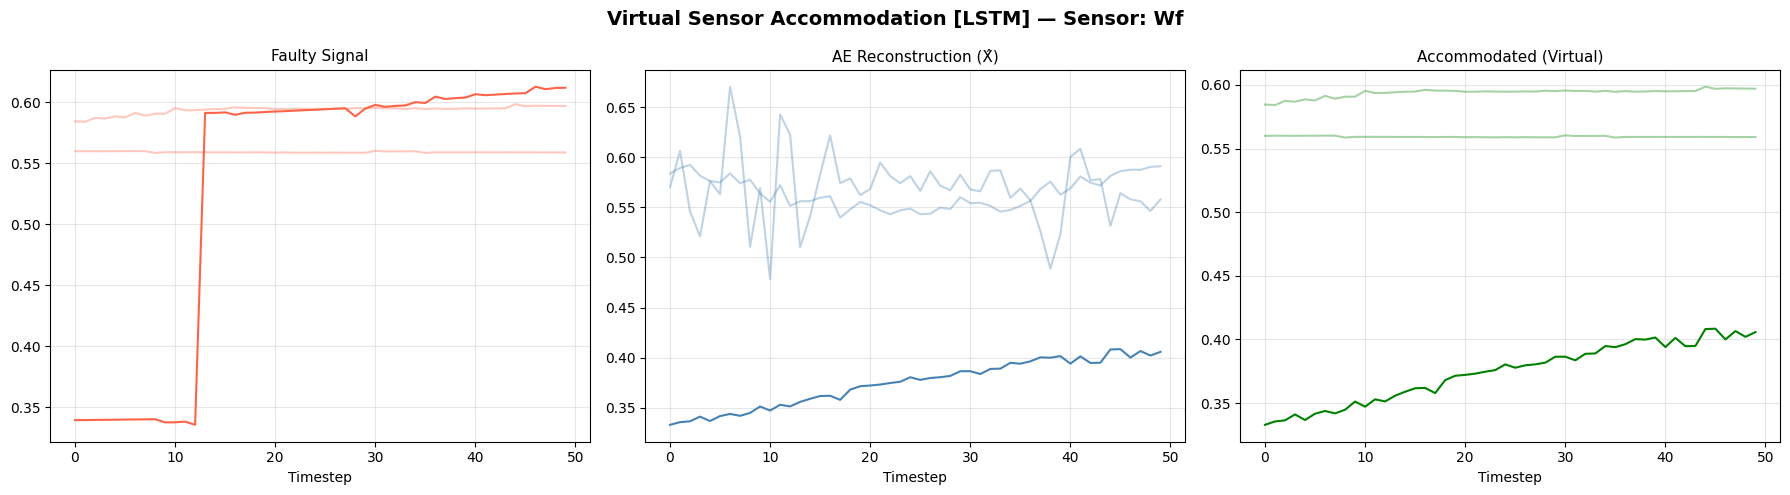

In [9]:
SENS_DEMO = int(sensor_preds[0]) if anomaly_mk.any() else 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle(
    f'Virtual Sensor Accommodation [{ACTIVE_MODEL}] — Sensor: {sensor_cols[SENS_DEMO]}',
    fontsize=14, fontweight='bold'
)

t_ = np.arange(WINDOW_SIZE)
for row in range(min(3, len(drift_win))):
    alpha = 1.0 if row == 0 else 0.35
    axes[0].plot(t_, drift_win[row, :, SENS_DEMO],   alpha=alpha, color='tomato',    lw=1.5)
    axes[1].plot(t_, drift_recon[row, :, SENS_DEMO], alpha=alpha, color='steelblue', lw=1.5)
    axes[2].plot(t_, X_acc[row, :, SENS_DEMO],       alpha=alpha, color='green',     lw=1.5)

for ax, title in zip(axes, ['Faulty Signal', 'AE Reconstruction (X̂)', 'Accommodated (Virtual)']):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Timestep'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb5_virtual_sensor_{ACTIVE_MODEL.lower()}.png', dpi=120)
plt.show()

## 6 — AE reconstruction error: nominal vs anomalous

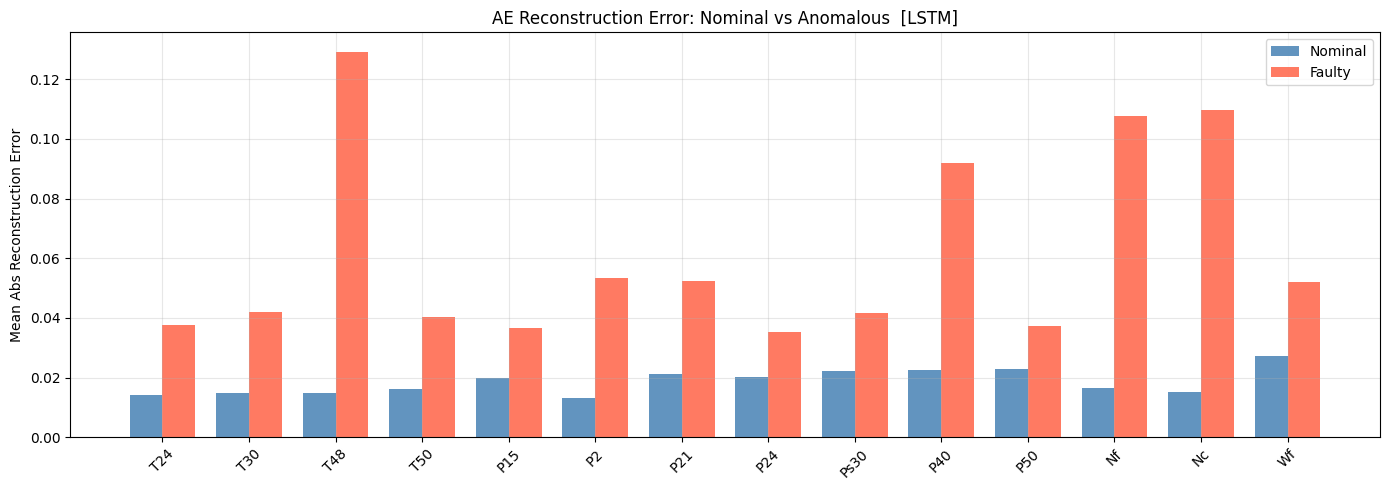

In [9]:
mae_faulty     = np.abs(drift_win - drift_recon).mean(axis=(0, 1))      # (S,)
mae_nominal_ps = np.abs(X_nom_sub[:len(drift_win)] -
                        ae_trainer.reconstruct(X_nom_sub[:len(drift_win)])).mean(axis=(0, 1))

x_pos = np.arange(len(sensor_cols))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_pos - width/2, mae_nominal_ps, width, label='Nominal',  color='steelblue', alpha=0.85)
ax.bar(x_pos + width/2, mae_faulty,     width, label='Faulty',   color='tomato',    alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(sensor_cols, rotation=45)
ax.set_ylabel('Mean Abs Reconstruction Error')
ax.set_title(f'AE Reconstruction Error: Nominal vs Anomalous  [{ACTIVE_MODEL}]')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/nb5_recon_error_{ACTIVE_MODEL.lower()}.png', dpi=120)
plt.show()

## 7 — Multi-model diagnostic comparison

If all three models were trained in NB3, run each orchestrator and compare their
fault-type and sensor-id predictions on the same test batch.

In [10]:
# Only run this cell if HEAD_TYPE == 'all'
if HEAD_TYPE != 'all':
    print(f'HEAD_TYPE={HEAD_TYPE} — skipping multi-model comparison (only relevant when all=True).')
else:
    from sklearn.metrics import accuracy_score

    COMPARE_N = 300
    cmp_idx   = np.random.choice(len(X_dataset), COMPARE_N, replace=False)
    X_cmp     = X_dataset[cmp_idx]
    y_cmp     = y_fault[cmp_idx]

    compare_results = {}   # model_name → pred_fault labels

    for m_name, ckpt_suffix in [('ANN', 'ann'), ('LSTM', 'lstm'), ('Transformer', 'transformer')]:
        ckpt = f'{CKPT_DIR}/{ckpt_suffix}_multihead.pt'
        if not os.path.exists(ckpt):
            continue

        # Load model
        if m_name == 'ANN':
            _d2   = np.load(f'{PROC_DIR}/final_manifold_features.npz')
            F_cmp = _d2['F'][cmp_idx]
            mdl   = MultiHeadANN(in_features=F_cmp.shape[1], n_fault_types=N_FAULT_TYPES,
                                  n_sensors=len(sensor_cols), hidden_dims=[256,128,64], dropout_p=0.3)
            mdl.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
            mdl.to(DEVICE).eval()
            inp_t = torch.from_numpy(F_cmp).float().to(DEVICE)

        elif m_name == 'LSTM':
            cfg2 = meta['lstm_config']
            mdl  = MultiHeadLSTM(n_sensors=N_SENSORS, hidden_size=cfg2['hidden_size'],
                                  num_layers=cfg2['num_layers'], n_fault_types=N_FAULT_TYPES,
                                  dropout_p=cfg2['dropout_p'], use_residual=USE_RESIDUAL)
            mdl.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
            mdl.to(DEVICE).eval()
            X_seq_cmp = (np.concatenate([X_cmp, np.abs(X_cmp - X_recon_all[cmp_idx]).astype(np.float32)], axis=-1)
                         if USE_RESIDUAL else X_cmp.astype(np.float32))
            inp_t = torch.from_numpy(X_seq_cmp).float().to(DEVICE)

        elif m_name == 'Transformer':
            cfg3 = meta['transformer_config']
            mdl  = MultiHeadTransformer(n_sensors=N_SENSORS, d_model=cfg3['d_model'],
                                         nhead=cfg3['nhead'], num_layers=cfg3['num_layers'],
                                         dim_feedforward=cfg3['dim_feedforward'],
                                         n_fault_types=N_FAULT_TYPES, dropout_p=cfg3['dropout_p'],
                                         use_residual=USE_RESIDUAL)
            mdl.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
            mdl.to(DEVICE).eval()
            X_seq_cmp_tf = (np.concatenate([X_cmp, np.abs(X_cmp - X_recon_all[cmp_idx]).astype(np.float32)], axis=-1)
                            if USE_RESIDUAL else X_cmp.astype(np.float32))
            inp_t = torch.from_numpy(X_seq_cmp_tf).float().to(DEVICE)

        mc_cmp = MCDropoutWrapper(mdl, T=50)
        preds  = mc_cmp.predict(inp_t, head='fault')['pred_class'].cpu().numpy()
        compare_results[m_name] = preds

    if compare_results:
        print(f'\nMulti-model accuracy on {COMPARE_N} windows:')
        print('=' * 45)
        for m_name, preds in compare_results.items():
            acc = accuracy_score(y_cmp, preds)
            print(f'  {m_name:12s}: {acc*100:.1f}%')

        # Per-class accuracy
        classes_ = sorted(np.unique(y_cmp))
        print('\nPer-class accuracy:')
        header = f"{'Class':<15}" + ''.join(f"{n:<14}" for n in compare_results)
        print(header)
        print('-' * len(header))
        for c in classes_:
            mask_c = y_cmp == c
            row = f"{label_names.get(c, str(c)):<15}"
            for preds in compare_results.values():
                acc_c = (preds[mask_c] == c).mean() if mask_c.sum() > 0 else float('nan')
                row += f"{acc_c*100:>6.1f}%       "
            print(row)


Multi-model accuracy on 300 windows:
  ANN         : 56.3%
  LSTM        : 74.0%
  Transformer : 54.0%

Per-class accuracy:
Class          ANN           LSTM          Transformer   
---------------------------------------------------------
Nominal          97.7%         95.5%         97.7%       
Bias             47.1%         97.1%         52.9%       
Scaling          94.9%         97.4%         94.9%       
Drift            40.0%         92.5%         60.0%       
Intermittent     52.9%         70.6%         20.6%       
Compound          0.0%         23.7%          7.9%       
MultiSensor      30.0%         27.5%          7.5%       
SystemFault      87.1%         90.3%         87.1%       


## 8 — Single-window inference demo (inject a synthetic fault)

In [11]:
engine   = FaultEngine(seed=99)
base_win = X_nominal[42].copy()
new_win, _, _, fault_type_true, mag_true = engine.inject_single_sensor_single_fault(
    base_win, fault_type='drift', sensor_idx=5, magnitude=0.45
)

print(f'Simulated fault: {fault_type_true}  |  magnitude: {mag_true:.3f}  |  sensor: {sensor_cols[5]}')

new_batch = new_win[np.newaxis, ...]   # (1, T, S)
reports_1, X_acc_1 = orchestrator.diagnose_batch(new_batch)
rpt = reports_1[0]

print('\n--- Diagnostic Report ---')
print(rpt)
print(f'\nTrue fault    : {fault_type_true.capitalize()}')
print(f'True sensor   : {sensor_cols[5]}')
print(f'True magnitude: {mag_true:.3f}')

2026-04-09 14:21:41,868 [INFO] FaultEngine initialized (seed=99, fs=1 Hz) | mag_range=[0.40, 0.80] | interm_range=[0.50, 2.00]


Simulated fault: drift  |  magnitude: 0.450  |  sensor: P2

--- Diagnostic Report ---
─── Diagnosis Report [Window 0] ───
  Timestamp      : 0.0 s
  Anomaly        : YES ⚠
  Severity       : 61.9%
  Confidence     : 0.76
  Fault Type     : Drift (p=0.63)
  Sensor ID      : P2 (p=0.85)
  Magnitude (est): 0.7036 ± 0.0258
  Accommodation  : VirtualSensor
  Top SHAP features / regions:
    t36__P21                       -300.7100
    t37__P21                       -300.5627
    t36__P24                       -295.1197
    t37__P24                       -294.4326
    t35__P21                       -290.6463

True fault    : Drift
True sensor   : P2
True magnitude: 0.450


In [12]:
# ── Structured Per-Case Evaluation for Thesis Presentation ───────────────────
from fault_engine import FaultEngine
import pandas as pd

engine_test = FaultEngine(seed=123)   # different seed from training

# Pick a nominal window as base for all synthetic tests
base_win = X_nominal[100].copy()

sensor_cols_list = list(sensor_cols)

test_cases = []

# ── Case 1: Single Sensor, Single Fault (one per fault type) ─────────────────
for fault_type in ['bias', 'scaling', 'drift', 'intermittent']:
    for sensor_idx in [2, 5, 11]:   # T48, P2, Nf — representative sensors
        win_f, s_idx, lbl, ft_str, mag = engine_test.inject_single_sensor_single_fault(
            base_win, fault_type=fault_type, sensor_idx=sensor_idx, magnitude=0.45
        )
        test_cases.append({
            'case': 1, 'description': f'Single/{fault_type}/{sensor_cols_list[sensor_idx]}',
            'true_fault': ft_str.capitalize(), 'true_sensor': sensor_cols_list[s_idx],
            'true_mag': mag, 'window': win_f[np.newaxis]
        })

# ── Case 2: Single Sensor, Compound Fault ────────────────────────────────────
for sensor_idx in [2, 7]:
    win_f, s_idx, lbl, seq = engine_test.inject_compound_fault(base_win, sensor_idx=sensor_idx)
    test_cases.append({
        'case': 2, 'description': f'Compound/{sensor_cols_list[sensor_idx]}',
        'true_fault': 'Compound', 'true_sensor': sensor_cols_list[s_idx],
        'true_mag': np.mean([s[1] for s in seq]), 'window': win_f[np.newaxis]
    })

# ── Case 3: Multi-Sensor Fault ────────────────────────────────────────────────
win_f, specs = engine_test.inject_multi_sensor_faults(base_win)
sensors_faulted = '+'.join([sensor_cols_list[sp.sensor_idx] for sp in specs])
test_cases.append({
    'case': 3, 'description': f'MultiSensor/{sensors_faulted}',
    'true_fault': 'MultiSensor', 'true_sensor': sensors_faulted,
    'true_mag': np.mean([sp.magnitude for sp in specs]), 'window': win_f[np.newaxis]
})

# ── Case 4: System Fault (use real degraded window from dataset) ──────────────
sf_mask = y_fault == 7
if sf_mask.sum() > 0:
    sf_win = X_dataset[sf_mask][0:1]
    test_cases.append({
        'case': 4, 'description': 'SystemFault/engine_degradation',
        'true_fault': 'SystemFault', 'true_sensor': 'N/A (engine-wide)',
        'true_mag': 0.5, 'window': sf_win
    })

# ── Case 5: Nominal ───────────────────────────────────────────────────────────
test_cases.append({
    'case': 5, 'description': 'Nominal/no_fault',
    'true_fault': 'Nominal', 'true_sensor': 'None', 'true_mag': 0.0,
    'window': base_win[np.newaxis]
})

print(f'Total test cases: {len(test_cases)}')
print()

# ── Run orchestrator on each test case ───────────────────────────────────────
rows = []
for tc in test_cases:
    reports, _ = orchestrator.diagnose_batch(tc['window'], stride_s=10.0)
    r = reports[0]
    correct_fault  = (r.fault_type == tc['true_fault'])
    correct_sensor = (r.sensor_id  == tc['true_sensor'] or tc['case'] in [3, 4, 5])
    rows.append({
        'Case':           tc['case'],
        'Description':    tc['description'],
        'True Fault':     tc['true_fault'],
        'Pred Fault':     r.fault_type,
        'Fault p':        f"{r.fault_type_prob:.2f}",
        'True Sensor':    tc['true_sensor'],
        'Pred Sensor':    r.sensor_id,
        'Sensor p':       f"{r.sensor_prob:.2f}",
        'True Mag':       f"{tc['true_mag']:.3f}",
        'Pred Mag':       f"{r.magnitude_est:.3f}",
        'Severity %':     f"{r.severity_pct:.1f}",
        'Anomaly':        'YES' if r.is_anomaly else 'no',
        'Fault Correct':  '✓' if correct_fault else '✗',
        'Sensor Correct': '✓' if correct_sensor else '✗',
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))
results_df.to_csv(f'{CKPT_DIR}/structured_test_results.csv', index=False)
print(f'\nSaved structured_test_results.csv')

# ── Summary table for thesis presentation ────────────────────────────────────
print('\n' + '='*70)
print('STRUCTURED TEST CASE SUMMARY')
print('='*70)

for case_num in [1, 2, 3, 4, 5]:
    case_rows = results_df[results_df['Case'] == case_num]
    n_total   = len(case_rows)
    n_fault_correct  = (case_rows['Fault Correct'] == '✓').sum()
    n_sensor_correct = (case_rows['Sensor Correct'] == '✓').sum()

    case_names = {1:'Single Sensor Single Fault', 2:'Compound Fault',
                  3:'Multi-Sensor', 4:'System Fault', 5:'Nominal'}
    print(f'\nCase {case_num}: {case_names[case_num]}')
    print(f'  Fault type accuracy : {n_fault_correct}/{n_total}')
    print(f'  Sensor accuracy     : {n_sensor_correct}/{n_total}')
    for _, row in case_rows.iterrows():
        status = '✓' if row['Fault Correct'] == '✓' else '✗'
        print(f'  {status} {row["Description"]:<45} '
              f'pred={row["Pred Fault"]:<15} conf={row["Fault p"]}  '
              f'sev={row["Severity %"]}%  anomaly={row["Anomaly"]}')


2026-04-09 14:22:05,956 [INFO] FaultEngine initialized (seed=123, fs=1 Hz) | mag_range=[0.40, 0.80] | interm_range=[0.50, 2.00]


Total test cases: 17

 Case                    Description   True Fault   Pred Fault Fault p       True Sensor Pred Sensor Sensor p True Mag Pred Mag Severity % Anomaly Fault Correct Sensor Correct
    1                Single/bias/T48         Bias         Bias    0.87               T48         T48     0.96    0.450    0.660       63.2     YES             ✓              ✓
    1                 Single/bias/P2         Bias      Nominal    0.59                P2         T24     0.61    0.450    0.459       62.0     YES             ✗              ✗
    1                 Single/bias/Nf         Bias         Bias    0.81                Nf          Nf     0.95    0.450    0.673       60.6     YES             ✓              ✓
    1             Single/scaling/T48      Scaling      Scaling    0.58               T48         T48     0.88    0.450    0.594      100.0     YES             ✓              ✓
    1              Single/scaling/P2      Scaling      Scaling    0.55                P2          

## 9 — Save results & framework summary

In [13]:
rpt_df.to_csv(f'{CKPT_DIR}/diagnostic_reports_{ACTIVE_MODEL.lower()}.csv', index=False)
print(f'Saved diagnostic_reports_{ACTIVE_MODEL.lower()}.csv')

summary = {
    'active_model'          : ACTIVE_MODEL,
    'head_type_trained'     : HEAD_TYPE,
    'use_residual'          : USE_RESIDUAL,
    'n_nominal_windows'     : int(len(X_nominal)),
    'n_total_windows'       : int(len(X_dataset)),
    'n_sensors'             : len(sensor_cols),
    'sensor_cols'           : list(sensor_cols),
    'window_size'           : int(WINDOW_SIZE),
    'ae_latent_dim'         : 64,
    'ae_nominal_mae'        : float(ae_nominal_mae),
    'mc_T'                  : 100,
    'fault_labels'          : FAULT_LABELS,
    'best_val_losses'       : best_val,
    'n_anomalies_detected'  : int(rpt_df['is_anomaly'].sum()),
    'n_windows_diagnosed'   : int(len(rpt_df)),
}

with open(f'{CKPT_DIR}/framework_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved framework_summary.json')

print('\n' + '─' * 60)
print('Checkpoints directory:')
for fn in sorted(os.listdir(CKPT_DIR)):
    sz = os.path.getsize(os.path.join(CKPT_DIR, fn))
    print(f'  {fn:42s}  {sz/1e3:>8.1f} KB')
print('─' * 60)
print(f'✓ NB5 complete — Full SVF pipeline finished  [{ACTIVE_MODEL}].')

Saved diagnostic_reports_lstm.csv
Saved framework_summary.json

────────────────────────────────────────────────────────────
Checkpoints directory:
  ae_thresholds.json                               0.1 KB
  ann_multihead.pt                               391.1 KB
  autoencoder.pt                                2000.1 KB
  diagnostic_reports_lstm.csv                     31.3 KB
  feature_pipeline.pkl                        307128.9 KB
  framework_summary.json                           0.9 KB
  global_scaler.pkl                                0.8 KB
  lstm_multihead.pt                             2724.3 KB
  nb3_meta.json                                    0.5 KB
  shap_explainers.pkl                         2929756.8 KB
  structured_test_results.csv                      1.6 KB
  transformer_multihead.pt                       570.9 KB
────────────────────────────────────────────────────────────
✓ NB5 complete — Full SVF pipeline finished  [LSTM].


---
## ↻ Reload Block

In [14]:
# ── Run this block only if kernel was restarted ──────────────────────────────
import sys, os, gc, pickle, warnings, json
import numpy as np, pandas as pd, torch
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
from models import (ConvAutoencoder, AETrainer, MultiHeadANN, MultiHeadLSTM,
                    MultiHeadTransformer, MCDropoutWrapper, apply_virtual_sensor, DEVICE)
from feature_engineering import FeaturePipeline
from explainability import SHAPExplainer, DiagnosticOrchestrator, DiagnosisReport, _apply_virtual
from fault_engine import FAULT_LABELS, FaultEngine

PROC_DIR = '../processed_data'; CKPT_DIR = '../checkpoints'; PLOT_DIR = '../plots'
label_names = {0:'Nominal',1:'Bias',2:'Scaling',3:'Drift',
               4:'Intermittent',5:'Compound',6:'MultiSensor',7:'SystemFault'}

with open(f'{PROC_DIR}/sensor_cols.pkl',  'rb') as f: sensor_cols = pickle.load(f)
with open(f'{CKPT_DIR}/nb3_meta.json')         as f: meta        = json.load(f)
HEAD_TYPE = meta['head_type']; USE_RESIDUAL = meta['use_residual']
N_SENSORS = meta['n_sensors']; WINDOW_SIZE = meta['window_size']
N_FAULT_TYPES = meta['n_fault_types']

X_nominal   = np.load(f'{PROC_DIR}/X_nominal.npy')
_raw        = np.load(f'{PROC_DIR}/augmented_dataset_with_recon.npz')
X_dataset   = _raw['X']; X_recon_all = _raw['X_rec']
y_fault     = _raw['y_f']; y_sensor  = _raw['y_s']; y_mag = _raw['y_m']

ae_model = ConvAutoencoder(n_sensors=N_SENSORS, window_size=WINDOW_SIZE, base_ch=32, latent_dim=64).to(DEVICE)
ae_model.load_state_dict(torch.load(f'{CKPT_DIR}/autoencoder.pt', map_location=DEVICE, weights_only=True))
ae_model.eval(); ae_trainer = AETrainer(ae_model, device=DEVICE)

with open(f'{CKPT_DIR}/framework_summary.json') as f: summary = json.load(f)
ACTIVE_MODEL = summary['active_model']
ae_nominal_mae = summary['ae_nominal_mae']
best_val = summary['best_val_losses']

feat_pipe = None
if ACTIVE_MODEL == 'ANN':
    _d = np.load(f'{PROC_DIR}/final_manifold_features.npz')
    F_all = _d['F']
    with open(f'{CKPT_DIR}/feature_pipeline.pkl', 'rb') as f: feat_pipe = pickle.load(f)
    active_clf = MultiHeadANN(in_features=F_all.shape[1], n_fault_types=N_FAULT_TYPES,
                               n_sensors=len(sensor_cols), hidden_dims=[256,128,64], dropout_p=0.3)
    active_clf.load_state_dict(torch.load(f'{CKPT_DIR}/ann_multihead.pt', map_location=DEVICE, weights_only=True))
elif ACTIVE_MODEL == 'LSTM':
    cfg = meta['lstm_config']
    active_clf = MultiHeadLSTM(n_sensors=N_SENSORS, hidden_size=cfg['hidden_size'],
                                num_layers=cfg['num_layers'], n_fault_types=N_FAULT_TYPES,
                                dropout_p=cfg['dropout_p'], use_residual=USE_RESIDUAL)
    active_clf.load_state_dict(torch.load(f'{CKPT_DIR}/lstm_multihead.pt', map_location=DEVICE, weights_only=True))
elif ACTIVE_MODEL == 'Transformer':
    cfg = meta['transformer_config']
    active_clf = MultiHeadTransformer(n_sensors=N_SENSORS, d_model=cfg['d_model'], nhead=cfg['nhead'],
                                       num_layers=cfg['num_layers'], dim_feedforward=cfg['dim_feedforward'],
                                       n_fault_types=N_FAULT_TYPES, dropout_p=cfg['dropout_p'],
                                       use_residual=USE_RESIDUAL)
    active_clf.load_state_dict(torch.load(f'{CKPT_DIR}/transformer_multihead.pt', map_location=DEVICE, weights_only=True))

active_clf.to(DEVICE).eval()
mc_wrapper = MCDropoutWrapper(active_clf, T=100)

shap_explainer = None
if os.path.exists(f'{CKPT_DIR}/shap_explainers.pkl'):
    with open(f'{CKPT_DIR}/shap_explainers.pkl', 'rb') as f: all_explainers = pickle.load(f)
    if ACTIVE_MODEL in all_explainers: shap_explainer, _ = all_explainers[ACTIVE_MODEL]

orchestrator = DiagnosticOrchestrator(
    ae_trainer=ae_trainer, mc_wrapper=mc_wrapper, sensor_cols=sensor_cols,
    fault_labels=FAULT_LABELS, shap_explainer=shap_explainer, feature_pipe=feat_pipe,
    severity_thresh=50.0, ae_nominal_mae=ae_nominal_mae,
    model_type=ACTIVE_MODEL, use_residual=USE_RESIDUAL,
)
print(f'✓ All models & artefacts reloaded  [{ACTIVE_MODEL} path]')

2026-04-09 14:22:55,370 [INFO] AE Bottleneck: 1792 -> 64 -> 1792
2026-04-09 14:22:56,830 [INFO] DiagnosticOrchestrator ready  model_type=LSTM  use_residual=True


✓ All models & artefacts reloaded  [LSTM path]
